In [26]:
import geopandas as gpd
import requests
import json
import io

In [13]:
types = [
    ["highway", "pedestrian"],
    ["cycleway", "lane"],
    ["cycleway", "track"],
    ["cycleway", "share_busway"],
    ["cycleway", "shared_lane"],
    ["busway", "lane"],
    ["highway", "footway"],
    ["highway", "bridleway"],
    ["highway", "steps"],
    ["highway", "corridor"],
    ["highway", "path"],
    ["highway", "via_ferrata"],
    ["footway", "sidewalk"],
    ["footway", "crossing"],
    ["footway", "traffic_island"],
    ["highway", "cycleway"]
]

In [20]:
areas = [
    ['Bratislava', 'administrative'],
    ['Ružinov', 'administrative']
]

In [28]:
def get_overpass_query(area: list[str], types: list[list[str]]) -> str:
    types_str = '\n  '.join([f'way["{key}"="{value}"](area.searchArea);' for key, value in types])

    area_name, area_boundary = area

    overpass_query = (
        '[out:json];\n'
        f'area["name"="{area_name}"]["boundary"="{area_boundary}"]->.searchArea;\n'
        '(\n'
        f'\t{types_str}\n'
        ');\n'
        'out geom;'
    )
    return overpass_query

get_overpass_query(areas[0], types)


'[out:json];\narea["name"="Bratislava"]["boundary"="administrative"]->.searchArea;\n(\n\tway["highway"="pedestrian"](area.searchArea);\n  way["cycleway"="lane"](area.searchArea);\n  way["cycleway"="track"](area.searchArea);\n  way["cycleway"="share_busway"](area.searchArea);\n  way["cycleway"="shared_lane"](area.searchArea);\n  way["busway"="lane"](area.searchArea);\n  way["highway"="footway"](area.searchArea);\n  way["highway"="bridleway"](area.searchArea);\n  way["highway"="steps"](area.searchArea);\n  way["highway"="corridor"](area.searchArea);\n  way["highway"="path"](area.searchArea);\n  way["highway"="via_ferrata"](area.searchArea);\n  way["footway"="sidewalk"](area.searchArea);\n  way["footway"="crossing"](area.searchArea);\n  way["footway"="traffic_island"](area.searchArea);\n  way["highway"="cycleway"](area.searchArea);\n);\nout geom;'

In [23]:
def get_geojson(overpass_query: str) -> dict:
    OVERPASS_URL = "http://overpass-api.de/api/interpreter"

    response = requests.get(OVERPASS_URL, params={'data': overpass_query})
    data = response.json()

    # Convert to GeoJSON format
    geojson = {
        "type": "FeatureCollection",
        "features": []
    }

    for element in data['elements']:
        if element['type'] == 'way':
            feature = {
                "type": "Feature",
                "geometry": {
                    "type": "LineString",
                    "coordinates": [[node['lon'], node['lat']] for node in element['geometry']]
                },
                "properties": element['tags']
            }
            geojson['features'].append(feature)

    return geojson

In [25]:
geojson = get_geojson(get_overpass_query(areas[1], types))
with open("bratislava_roads.geojson", "w") as f:
    json.dump(geojson, f)


AttributeError: module 'geopandas' has no attribute 'from_features'

In [ ]:
#   way["cycleway"](area.searchArea);
#   way["footway"](area.searchArea);
#   way["path"](area.searchArea);

In [12]:


# Overpass API endpoint
OVERPASS_URL = "http://overpass-api.de/api/interpreter"

# Overpass query for roads, pavements, and bike lanes in Bratislava
overpass_query = """
[out:json];
area["name"="Bratislava"]["boundary"="administrative"]->.searchArea;
(
  way["highway"="pedestrian"](area.searchArea);
);
out geom;
"""

# Request the data from the Overpass API
response = requests.get(OVERPASS_URL, params={'data': overpass_query})
data = response.json()

# Convert to GeoJSON format
geojson = {
    "type": "FeatureCollection",
    "features": []
}

for element in data['elements']:
    if element['type'] == 'way':
        feature = {
            "type": "Feature",
            "geometry": {
                "type": "LineString",
                "coordinates": [[node['lon'], node['lat']] for node in element['geometry']]
            },
            "properties": element['tags']
        }
        geojson['features'].append(feature)


print(geojson)
# Save the output as a GeoJSON file
# with open("bratislava_roads.geojson", "w") as f:
#     json.dump(geojson, f)

# print("GeoJSON file created successfully: bratislava_roads.geojson")


{'type': 'FeatureCollection', 'features': [{'type': 'Feature', 'geometry': {'type': 'LineString', 'coordinates': [[17.1084707, 48.147975], [17.1084937, 48.1479579], [17.1085503, 48.1479142], [17.1086709, 48.1477601], [17.1090552, 48.1472691], [17.1092511, 48.1470187], [17.1092662, 48.1470005], [17.1092855, 48.1469772], [17.1092971, 48.1469632], [17.1093083, 48.1469505], [17.1093241, 48.1469326], [17.1093408, 48.1469136]]}, 'properties': {'bicycle': 'yes', 'highway': 'pedestrian', 'lit': 'yes', 'maxweight': '5', 'name': 'Poštová', 'name:de': 'Postgasse', 'name:hu': 'Posta utca', 'smoothness': 'excellent', 'source': 'http://www.pammap.sk/bratislava?miesta=1289', 'surface': 'paving_stones'}}, {'type': 'Feature', 'geometry': {'type': 'LineString', 'coordinates': [[17.1091461, 48.1451411], [17.1091345, 48.1451008], [17.1091293, 48.1450818], [17.1091273, 48.1450712], [17.1091269, 48.1450617], [17.1091278, 48.145054], [17.10913, 48.1450459], [17.1091359, 48.1450307], [17.1092463, 48.1448219]]

In [4]:
xx = gpd.read_file('bratislava_roads.geojson')

<Axes: >

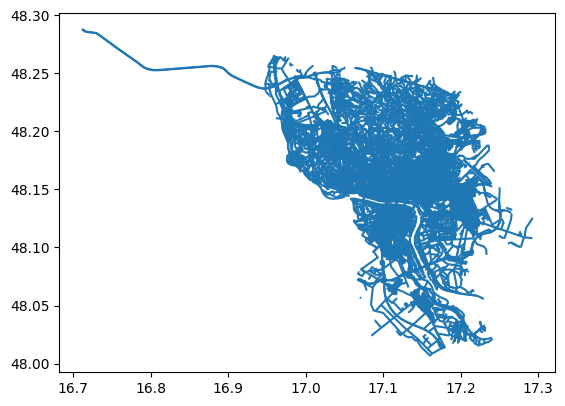

In [5]:
xx.plot()

In [6]:
xx.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 69980 entries, 0 to 69979
Columns: 467 entries, FIXME to geometry
dtypes: datetime64[ms](9), geometry(1), object(457)
memory usage: 249.3+ MB


In [7]:
xx.describe()

,check_date,check_date:cycleway:surface,check_date:handrail,check_date:lit,check_date:ramp,check_date:smoothness,check_date:surface,check_date:tactile_paving,opening_date
count,38,1,10,1,18,7,268,1,4
mean,2022-07-25 11:22:06.315000,2024-07-26 00:00:00,2022-05-23 14:24:00,2022-09-10 00:00:00,2023-04-10 13:20:00,2024-07-10 20:34:17.142000,2023-10-09 16:17:54.626000,2024-07-25 00:00:00,2024-02-14 06:00:00
min,2020-11-20 00:00:00,2024-07-26 00:00:00,2021-09-13 00:00:00,2022-09-10 00:00:00,2021-08-29 00:00:00,2023-03-12 00:00:00,2020-11-29 00:00:00,2024-07-25 00:00:00,2023-11-30 00:00:00
25%,2020-11-20 00:00:00,2024-07-26 00:00:00,2021-09-13 00:00:00,2022-09-10 00:00:00,2022-06-30 00:00:00,2024-09-30 00:00:00,2023-06-16 00:00:00,2024-07-25 00:00:00,2023-11-30 00:00:00
50%,2022-09-04 00:00:00,2024-07-26 00:00:00,2021-09-13 00:00:00,2022-09-10 00:00:00,2023-07-04 00:00:00,2024-09-30 00:00:00,2023-11-13 00:00:00,2024-07-25 00:00:00,2024-01-15 00:00:00
75%,2024-04-06 12:00:00,2024-07-26 00:00:00,2023-01-28 06:00:00,2022-09-10 00:00:00,2023-12-15 18:00:00,2024-09-30 00:00:00,2024-05-08 18:00:00,2024-07-25 00:00:00,2024-03-31 06:00:00
max,2024-10-01 00:00:00,2024-07-26 00:00:00,2024-10-19 00:00:00,2022-09-10 00:00:00,2024-04-06 00:00:00,2024-09-30 00:00:00,2024-10-09 00:00:00,2024-07-25 00:00:00,2024-06-30 00:00:00


In [8]:
xx.head()

,FIXME,abandoned:highway,abutters,access,access:conditional,access:lanes,agricultural,agricultural:lanes,alt_name,alt_name:de,...,voltage,was:highway,waterway,wheelchair,width,width:lanes,wikidata,wikimedia_commons,wikipedia,geometry
0,None,None,None,None,None,None,None,None,None,None,...,None,None,None,None,None,None,None,None,None,"LINESTRING (17.1671 48.16484, 17.1671 48.16481..."
1,None,None,None,None,None,None,None,None,None,None,...,None,None,None,None,None,None,None,None,None,"LINESTRING (17.12839 48.15705, 17.12868 48.157..."
2,None,None,residential,None,None,None,None,None,None,None,...,None,None,None,None,None,None,None,None,None,"LINESTRING (17.11578 48.15443, 17.11592 48.154..."
3,None,None,None,None,None,None,None,None,None,None,...,None,None,None,None,None,None,None,None,None,"LINESTRING (17.14192 48.14459, 17.14199 48.144..."
4,None,None,None,None,None,None,None,None,None,None,...,None,None,None,None,None,None,Q12763000,None,None,"LINESTRING (17.21111 48.14121, 17.21153 48.140..."


In [11]:
xx['width'].unique()

array([None, '7', '10', '4.8', '5.8', '5', '9', '11', '5.4', '6.5', '3.4',
       '7.5', '3.5', '5.7', '3.7', '8', '4.5', '4.7', '6', '4', '2',
       '7.1', '3', '4.2', '3.2', '5.3', '5.5', '7.9', '3.3', '4.1', '0.5',
       '12', '10 m', 'Q105688661', '1.5', '3.6', '1', '6.9', '6.7', '2.5',
       '3.9', '8.5', '2.9', '1.4', '2.4', '4.3', '0.3', '+', '1.5 m',
       '3.8', '7.4', '1.25', '0.8', '6 m', '1.6', '4.9', '0.7', '2.8',
       '1.8', '0.9', '0.4', '12.6', '1.2', '5.9', '0.5 m', '0.85', '7.7',
       '1m', '6.1', '1.3', '4.6'], dtype=object)